# UPI Fraud Detection — Phase 1: EDA & Preprocessing

In [1]:
import sys
print(sys.executable)
print(sys.version)

d:\upi-fraud-detection\ml\venv\Scripts\python.exe
3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]


## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print("✅ All libraries imported successfully")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Seaborn : {sns.__version__}")

✅ All libraries imported successfully
Pandas  : 3.0.3
NumPy   : 2.4.6
Seaborn : 0.13.2


## Step 2: Load Dataset

In [3]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'upi_fraud.csv')

df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded successfully")
print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns:")
for i, col in enumerate(df.columns):
    print(f"  {i:2d}. {col}  |  dtype: {df[col].dtype}  |  nulls: {df[col].isnull().sum()}  |  unique: {df[col].nunique()}")

✅ Dataset loaded successfully
Shape : 26,393 rows × 65 columns

Columns:
   0. transaction_id  |  dtype: str  |  nulls: 0  |  unique: 26393
   1. user_id  |  dtype: str  |  nulls: 0  |  unique: 4818
   2. merchant_id  |  dtype: str  |  nulls: 0  |  unique: 6544
   3. amount  |  dtype: float64  |  nulls: 0  |  unique: 26393
   4. timestamp  |  dtype: str  |  nulls: 0  |  unique: 18748
   5. description  |  dtype: str  |  nulls: 0  |  unique: 6915
   6. device_id  |  dtype: str  |  nulls: 0  |  unique: 6455
   7. ip_address  |  dtype: str  |  nulls: 0  |  unique: 26393
   8. location  |  dtype: str  |  nulls: 0  |  unique: 15230
   9. session_duration  |  dtype: int64  |  nulls: 0  |  unique: 520
  10. authentication_attempts  |  dtype: int64  |  nulls: 0  |  unique: 5
  11. receiver_account_age  |  dtype: int64  |  nulls: 0  |  unique: 703
  12. receiver_transaction_history  |  dtype: int64  |  nulls: 0  |  unique: 101
  13. transaction_amount_vs_sender_history  |  dtype: float64  |  nu

## Step 3: First Look at the Data

In [4]:
print("FIRST 5 ROWS")
display(df.head())

FIRST 5 ROWS


,transaction_id,user_id,merchant_id,amount,timestamp,description,device_id,ip_address,location,session_duration,authentication_attempts,receiver_account_age,receiver_transaction_history,transaction_amount_vs_sender_history,geographic_disparity,transaction_time_of_day,merchant_category_code,session_source,url_referrer,time_between_link_click_and_transaction,unusual_device_flag,unusual_ip_flag,unusual_location_flag,dns_lookup_age,recent_app_installs,input_timing_consistency,app_switching_frequency,keyboard_input_speed,input_pause_patterns,permissions_granted,screen_active_time,geographic_location_vs_ip,background_data_usage,recognized_screen_sharing_apps,authentication_attempt_count,time_between_otp_generation_and_input,pin_entry_method,pin_entry_speed,unusual_transaction_amount_flag,otp_request_frequency,otp_request_device_consistency,transaction_velocity,failed_transaction_count,authorization_method,transaction_type,request_description,request_description_keywords,request_amount_roundness,request_frequency,request_acceptance_rate,time_to_respond_to_request,time_pressure_indicators,requester_account_age,relationship_to_requester,upi_handle_age,handle_similarity_score,handle_contains_official_terms,handle_typo_analysis,handle_transaction_history,business_name_match,social_media_presence,handle_registration_pattern,handle_to_description_consistency,handle_verification_status,is_fraud
0,7d4e9561-000c-44c8-84e4-54af2c4ac209,michelle89,8bdff36c-efba-4260-a801-8bd36f0f2eb0,1960.7547,18:27.7,Payment to Lee-Warren for products,0c51ef4f-41a8-41da-b721-b74a8055dc4c,49.221.248.16,"(14.5837385, 85.305345)",234,1,350,7,1.2738,11080.7968,23,food,app,NaN,0,0,0,0,0,[],0.9009,0,1.1727,0.0768,[],262,11080.7968,0.3338,[],1,0,manual,1.2519,0,0,1,0,0,pin,payment,NaN,[],1.0001,0,0.0000,0,0,0,unknown,0,0.0000,0,none,0,none,none,none,0,verified,0
1,fbf88cde-dc62-4f36-ac10-a1b1fd771793,eguerrero,a28f2b48-5423-4eb6-9018-00e6e55410af,4593.8546,34:55.5,"Payment to Wright, Johnson and Parker for prod...",932aab8b-af95-4214-b555-7f5f2d67308c,106.79.40.40,"(-41.063726, -164.178102)",98,1,29,61,4.9461,7582.4843,14,food,app,NaN,0,0,0,0,0,[],0.9127,2,1.0802,0.0965,[],542,7582.4843,0.1516,[],1,0,manual,0.6986,0,0,1,0,0,pin,payment,NaN,[],1.0000,0,0.0000,0,0,0,unknown,0,0.0000,0,none,0,none,none,none,0,verified,0
2,d746c963-baaa-46a0-80f4-b050e14e1c7d,alexanderpatrick,ce4ed336-6b99-42f2-88ca-dba320b8a96f,1949.5872,49:42.8,Payment to Hanson Ltd for products,0dc46fa1-fb1f-4bc6-9e03-af19e1c46e1b,125.165.248.30,"(52.1582705, -162.522989)",100,1,166,10,0.8715,3398.5894,2,services,app,NaN,0,0,0,0,0,[],0.9612,2,1.3027,0.0979,[],598,3398.5894,0.2869,[],1,0,manual,1.7085,0,0,1,0,0,pin,payment,NaN,[],1.0002,0,0.0000,0,0,0,unknown,0,0.0000,0,none,0,none,none,none,0,verified,0
3,e5f8a1cc-4bf6-46d2-b9b2-aa393ff4e244,timothy32,3a6129b8-6cdd-4c5a-9bf5-a312da5a9fd3,2825.5699,16:29.9,"Payment to Garcia, Barron and Wood for services",2cc9e843-b5b2-41cf-a6db-aa7fc659986a,89.223.179.179,"(48.549751, -163.02585)",145,1,360,20,21.4459,10979.2897,7,utilities,app,NaN,0,0,0,0,0,[],0.8673,0,1.2542,0.1240,[],503,10979.2897,0.2121,[],1,0,manual,0.9924,0,0,1,0,0,pin,payment,NaN,[],1.0002,0,0.0000,0,0,0,unknown,0,0.0000,0,none,0,none,none,none,0,verified,0
4,34309820-3aec-4fa4-9518-03437830e1e0,billycalhoun,2e34ad70-ec10-4ac1-895e-2773c6246f62,6509.6284,39:44.7,Payment via link: http://lowe.com/search/wp-co...,b503c1d9-fd00-4289-93b9-e297c98f0228,156.93.45.217,"(-61.0860645, 18.331554)",13,1,0,5,0.9901,9626.4101,3,unknown,link,http://lowe.com/search/wp-content/wp-contentma...,8,1,1,1,7,[],0.6974,0,0.5244,0.3919,[],188,15492.4819,0.7923,[],3,0,manual,1.0183,1,0,0,0,0,pin,payment,NaN,[],0.9977,0,0.0000,0,2,0,unknown,0,0.0000,0,none,0,none,none,none,0,unverified,1


In [5]:
print("STATISTICAL SUMMARY")
display(df.describe())

STATISTICAL SUMMARY


,amount,session_duration,authentication_attempts,receiver_account_age,receiver_transaction_history,transaction_amount_vs_sender_history,geographic_disparity,transaction_time_of_day,time_between_link_click_and_transaction,unusual_device_flag,unusual_ip_flag,unusual_location_flag,dns_lookup_age,input_timing_consistency,app_switching_frequency,keyboard_input_speed,input_pause_patterns,screen_active_time,geographic_location_vs_ip,background_data_usage,authentication_attempt_count,time_between_otp_generation_and_input,pin_entry_speed,unusual_transaction_amount_flag,otp_request_frequency,otp_request_device_consistency,transaction_velocity,failed_transaction_count,request_amount_roundness,request_frequency,request_acceptance_rate,time_to_respond_to_request,time_pressure_indicators,requester_account_age,upi_handle_age,handle_similarity_score,handle_contains_official_terms,handle_transaction_history,handle_to_description_consistency,is_fraud
count,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000,26393.0000
mean,4865.3671,161.6250,1.1086,150.2885,42.3326,3.0375,10005.3548,11.0074,0.4998,0.0565,0.0549,0.0549,0.0998,0.8787,1.2340,0.9484,0.1222,356.1037,9986.9924,0.2946,1.1397,0.3431,1.1891,0.1159,0.0829,0.9435,0.0967,0.0566,1.0430,0.2109,0.0055,0.4799,0.1951,0.0984,0.0000,0.0066,0.0000,0.0732,0.0283,0.1722
std,5720.5085,89.4533,0.5432,161.2976,31.5598,7.6097,4712.0049,7.0713,3.1832,0.2308,0.2278,0.2278,0.6989,0.1030,1.6951,0.3324,0.1275,148.6270,4699.1056,0.2629,0.5906,2.1694,0.4862,0.3202,0.5097,0.2308,0.6004,0.3625,0.4515,1.2792,0.0341,3.0989,0.7287,0.6969,0.0000,0.0599,0.0000,0.5155,0.1658,0.3776
min,139.2677,5.0000,1.0000,0.0000,0.0000,0.2228,14.1674,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3004,0.0000,0.1003,0.0000,60.0000,14.1674,0.0000,1.0000,0.0000,0.1004,0.0000,0.0000,0.0000,0.0000,0.0000,0.1091,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,2425.4842,88.0000,1.0000,13.0000,11.0000,0.9550,6307.0371,5.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8391,0.0000,0.6864,0.0508,230.0000,6300.8634,0.1306,1.0000,0.0000,0.8080,0.0000,0.0000,1.0000,0.0000,0.0000,0.9999,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,3685.5750,156.0000,1.0000,96.0000,40.0000,1.5140,10008.8657,10.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8921,1.0000,0.9580,0.1017,351.0000,9981.9211,0.2590,1.0000,0.0000,1.2049,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,5239.9943,231.0000,1.0000,240.0000,70.0000,2.6237,13708.7584,17.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.9465,2.0000,1.2281,0.1568,478.0000,13684.5750,0.3944,1.0000,0.0000,1.5993,0.0000,0.0000,1.0000,0.0000,0.0000,1.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
max,49970.1586,600.0000,5.0000,723.0000,100.0000,294.6287,19983.4779,23.0000,30.0000,1.0000,1.0000,1.0000,7.0000,1.0000,15.0000,1.5000,0.9992,899.0000,19983.4779,2.0000,5.0000,20.0000,2.0000,1.0000,4.0000,1.0000,5.0000,3.0000,9.3750,10.0000,0.2998,30.0000,5.0000,7.0000,0.0000,0.6000,0.0000,5.0000,1.0000,1.0000


In [6]:
print("DATASET INFO")
df.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 26393 entries, 0 to 26392
Data columns (total 65 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   transaction_id                           26393 non-null  str    
 1   user_id                                  26393 non-null  str    
 2   merchant_id                              26393 non-null  str    
 3   amount                                   26393 non-null  float64
 4   timestamp                                26393 non-null  str    
 5   description                              26393 non-null  str    
 6   device_id                                26393 non-null  str    
 7   ip_address                               26393 non-null  str    
 8   location                                 26393 non-null  str    
 9   session_duration                         26393 non-null  int64  
 10  authentication_attempts                  263

## Step 4: Check Target Column & Class Balance

In [7]:
# Find the fraud label column
target_col = 'is_fraud'  # we will confirm after running Cell 5

print(f"Target column : {target_col}")
print(f"\nValue counts:")
print(df[target_col].value_counts())
print(f"\nClass distribution (%):")
print(df[target_col].value_counts(normalize=True).mul(100).round(2))

Target column : is_fraud

Value counts:
is_fraud
0    21848
1     4545
Name: count, dtype: int64

Class distribution (%):
is_fraud
0   82.7800
1   17.2200
Name: proportion, dtype: float64


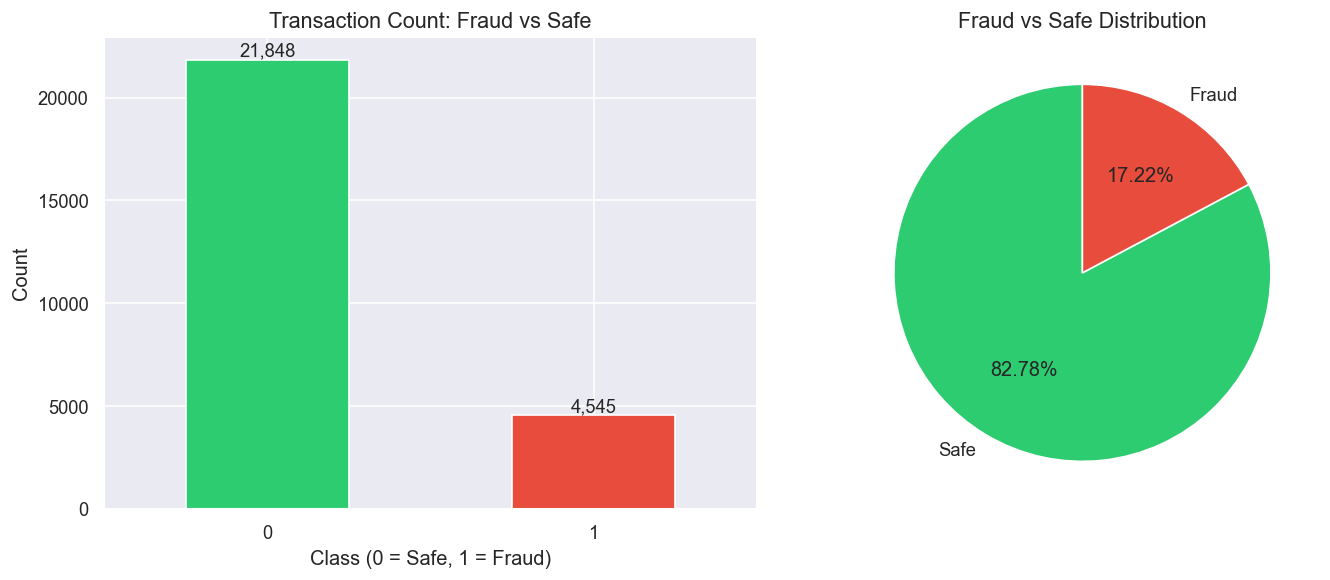

✅ Plot saved to models/class_balance.png


In [8]:
# Visualize class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
df[target_col].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='white'
)
axes[0].set_title('Transaction Count: Fraud vs Safe', fontsize=13)
axes[0].set_xlabel('Class (0 = Safe, 1 = Fraud)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
df[target_col].value_counts().plot(
    kind='pie', ax=axes[1],
    labels=['Safe', 'Fraud'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.2f%%', startangle=90
)
axes[1].set_title('Fraud vs Safe Distribution', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'models', 'class_balance.png'), dpi=120)
plt.show()
print("✅ Plot saved to models/class_balance.png")

## Step 5: Missing Values & Duplicates

In [9]:
print("MISSING VALUES")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) == 0:
    print("✅ No missing values found!")
else:
    display(missing_df)

print(f"\nDUPLICATE ROWS : {df.duplicated().sum()}")

MISSING VALUES


,Missing Count,Missing %
url_referrer,25636,97.1300
request_description,25661,97.2300



DUPLICATE ROWS : 0


In [10]:
# Handle missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"  Filled {col} with median")
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"  Filled {col} with mode")

# Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"\n✅ Duplicates removed : {before - after}")
print(f"✅ Final shape        : {df.shape}")

  Filled url_referrer with mode
  Filled request_description with mode

✅ Duplicates removed : 0
✅ Final shape        : (26393, 65)


## Step 6: Exploratory Data Analysis (EDA)

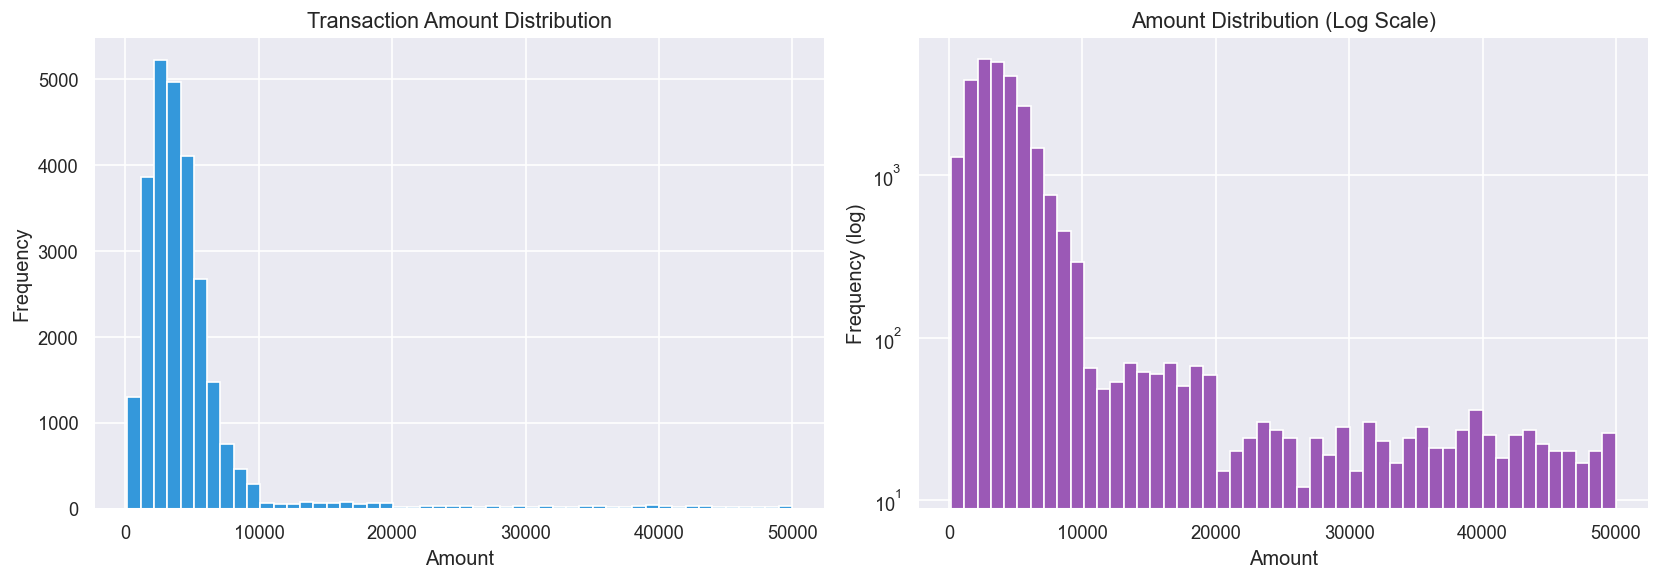

In [11]:
# Transaction amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['amount'], bins=50, color='#3498db', edgecolor='white')
axes[0].set_title('Transaction Amount Distribution', fontsize=13)
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

axes[1].hist(df[df['amount'] > 0]['amount'], bins=50,
             color='#9b59b6', edgecolor='white', log=True)
axes[1].set_title('Amount Distribution (Log Scale)', fontsize=13)
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency (log)')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'models', 'amount_distribution.png'), dpi=120)
plt.show()

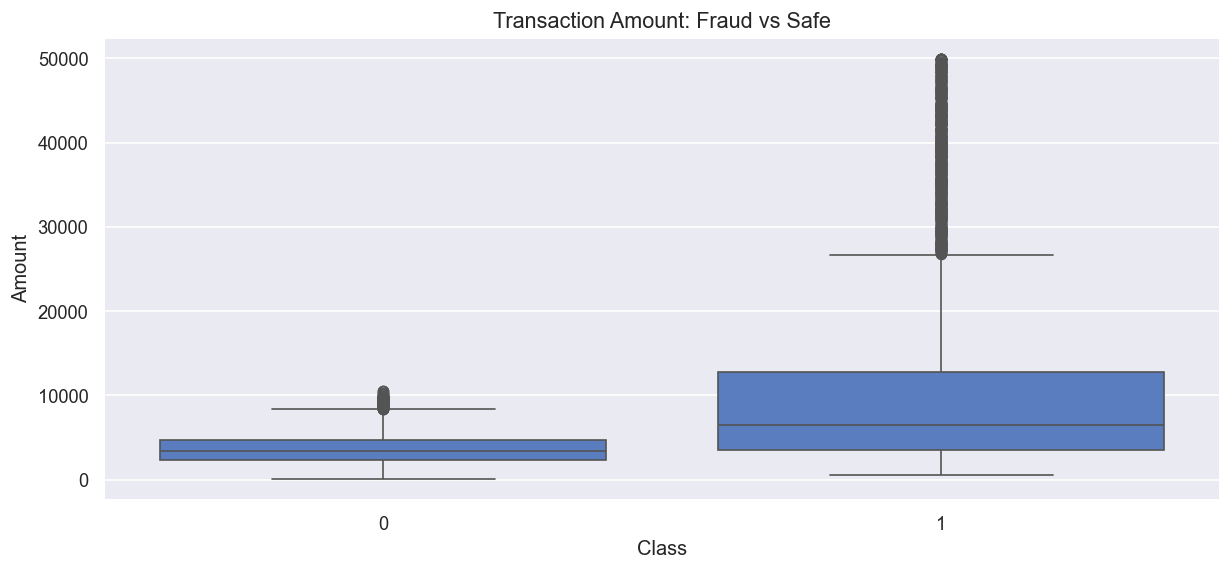

In [12]:
# Amount by fraud vs safe
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x=target_col, y='amount')
plt.title('Transaction Amount: Fraud vs Safe', fontsize=13)
plt.xlabel('Class')
plt.ylabel('Amount')
plt.savefig(os.path.join(BASE_DIR, 'models', 'amount_by_class.png'), dpi=120)
plt.show()

Numerical columns: ['amount', 'session_duration', 'authentication_attempts', 'receiver_account_age', 'receiver_transaction_history', 'transaction_amount_vs_sender_history', 'geographic_disparity', 'transaction_time_of_day', 'time_between_link_click_and_transaction', 'unusual_device_flag', 'unusual_ip_flag', 'unusual_location_flag', 'dns_lookup_age', 'input_timing_consistency', 'app_switching_frequency', 'keyboard_input_speed', 'input_pause_patterns', 'screen_active_time', 'geographic_location_vs_ip', 'background_data_usage', 'authentication_attempt_count', 'time_between_otp_generation_and_input', 'pin_entry_speed', 'unusual_transaction_amount_flag', 'otp_request_frequency', 'otp_request_device_consistency', 'transaction_velocity', 'failed_transaction_count', 'request_amount_roundness', 'request_frequency', 'request_acceptance_rate', 'time_to_respond_to_request', 'time_pressure_indicators', 'requester_account_age', 'upi_handle_age', 'handle_similarity_score', 'handle_contains_official_t

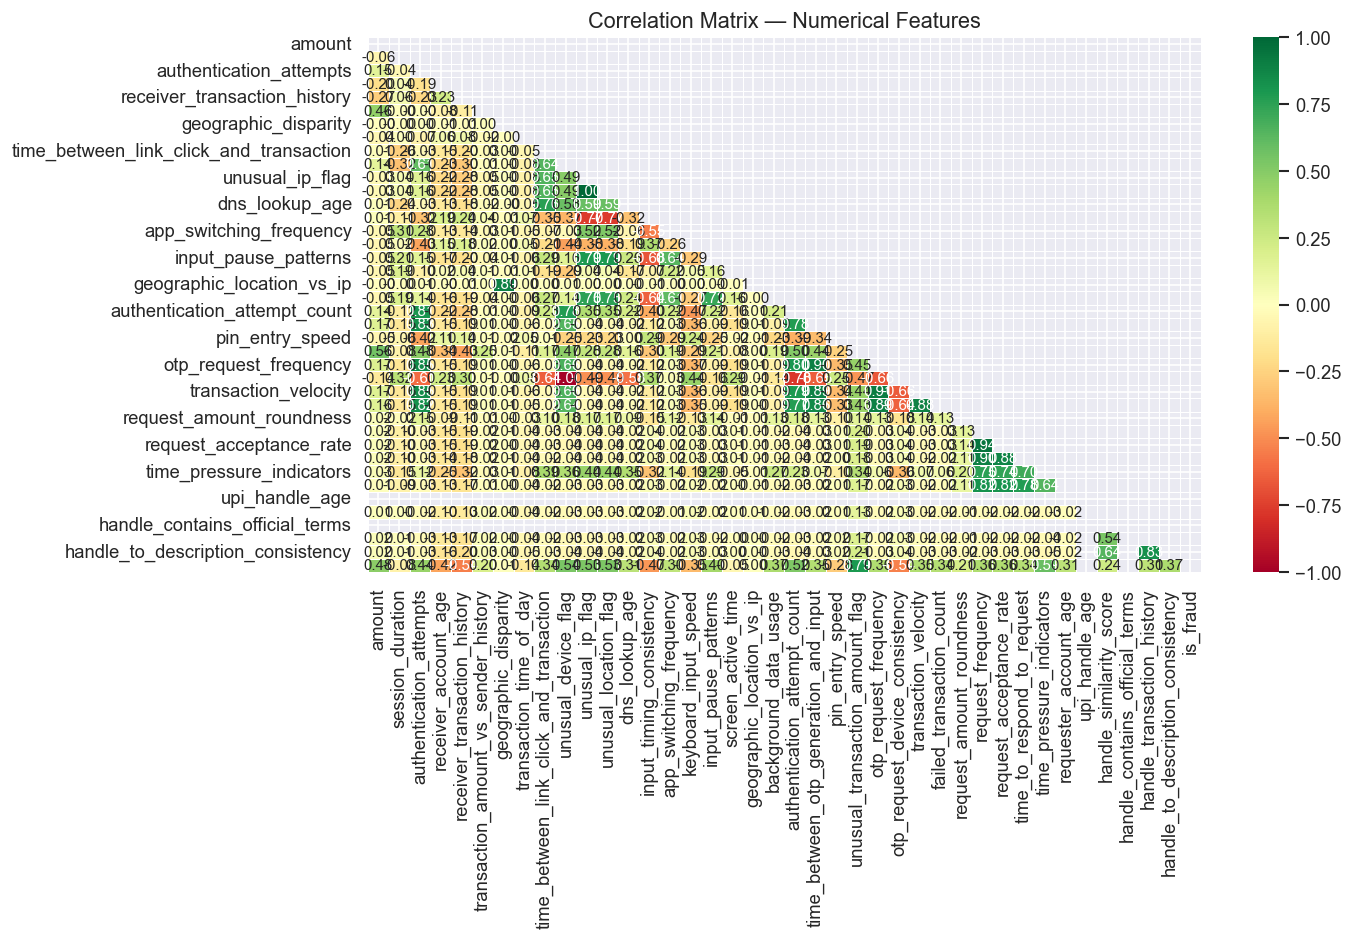

In [13]:
# Correlation heatmap (numerical columns only)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

plt.figure(figsize=(12, 8))
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Matrix — Numerical Features', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'models', 'correlation_heatmap.png'), dpi=120)
plt.show()

## Step 7: Feature Engineering

In [14]:
# Parse timestamp and extract time features
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

df['hour_of_day']   = df['timestamp'].dt.hour
df['day_of_week']   = df['timestamp'].dt.dayofweek
df['is_weekend']    = (df['day_of_week'] >= 5).astype(int)
df['is_night']      = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] <= 5)).astype(int)
df['month']         = df['timestamp'].dt.month

print("✅ Time features created:")
print(df[['timestamp', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'month']].head())

✅ Time features created:
            timestamp  hour_of_day  day_of_week  is_weekend  is_night  month
0 2026-05-26 18:27:42      18.0000       1.0000           0         0 5.0000
1                 NaT          NaN          NaN           0         0    NaN
2                 NaT          NaN          NaN           0         0    NaN
3 2026-05-26 16:29:54      16.0000       1.0000           0         0 5.0000
4                 NaT          NaN          NaN           0         0    NaN


In [15]:
# Amount-based features
df['amount_log']    = np.log1p(df['amount'])
df['is_high_value'] = (df['amount'] > df['amount'].quantile(0.95)).astype(int)
df['amount_zscore'] = (df['amount'] - df['amount'].mean()) / df['amount'].std()

print("✅ Amount features created")
print(df[['amount', 'amount_log', 'is_high_value', 'amount_zscore']].describe())

✅ Amount features created
          amount  amount_log  is_high_value  amount_zscore
count 26393.0000  26393.0000     26393.0000     26393.0000
mean   4865.3671      8.1917         0.0500         0.0000
std    5720.5085      0.7098         0.2180         1.0000
min     139.2677      4.9436         0.0000        -0.8262
25%    2425.4842      7.7942         0.0000        -0.4265
50%    3685.5750      8.2125         0.0000        -0.2062
75%    5239.9943      8.5643         0.0000         0.0655
max   49970.1586     10.8192         1.0000         7.8848


In [16]:
# Transaction frequency per user
df['user_tx_count'] = df.groupby('user_id')['user_id'].transform('count')
df['user_tx_mean_amount'] = df.groupby('user_id')['amount'].transform('mean')
df['amount_vs_user_mean'] = df['amount'] / (df['user_tx_mean_amount'] + 1)

print("✅ User behaviour features created")
print(df[['user_id', 'user_tx_count', 'user_tx_mean_amount', 'amount_vs_user_mean']].head(10))

✅ User behaviour features created
            user_id  user_tx_count  user_tx_mean_amount  amount_vs_user_mean
0        michelle89              9            5976.4115               0.3280
1         eguerrero              8            2837.5006               1.6184
2  alexanderpatrick              7            4314.2278               0.4518
3         timothy32              6            3080.9602               0.9168
4      billycalhoun              3            5050.8872               1.2886
5    zacharynielsen              4            2503.7215               0.9465
6             hfrye              4            3691.7985               0.6286
7      rogerjohnson              2            2413.1720               1.0100
8           linda77              6            4244.7336               0.0569
9         crystal81              4            5177.3447               0.9622


## Step 8: Encoding & Preprocessing

In [17]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_processed = df.copy()

# Drop ID/metadata columns
drop_cols = ['transaction_id', 'user_id', 'merchant_id',
             'timestamp', 'description', 'ip_address']

# Drop leaky columns (these are post-fraud flags, not input features)
leaky_cols = [
    'handle_verification_status',
    'unusual_transaction_amount_flag',
    'unusual_device_flag',
    'unusual_ip_flag',
    'unusual_location_flag',
    'time_pressure_indicators',
    'handle_registration_pattern',
    'receiver_transaction_history',
    'otp_request_device_consistency',
]

all_drop = drop_cols + leaky_cols
all_drop = [c for c in all_drop if c in df_processed.columns]
df_processed.drop(columns=all_drop, inplace=True)

print(f"✅ Dropped {len(all_drop)} columns:")
for c in all_drop:
    print(f"   - {c}")
print(f"\nRemaining columns : {df_processed.shape[1]}")

✅ Dropped 15 columns:
   - transaction_id
   - user_id
   - merchant_id
   - timestamp
   - description
   - ip_address
   - handle_verification_status
   - unusual_transaction_amount_flag
   - unusual_device_flag
   - unusual_ip_flag
   - unusual_location_flag
   - time_pressure_indicators
   - handle_registration_pattern
   - receiver_transaction_history
   - otp_request_device_consistency

Remaining columns : 61


In [18]:
# Label encode categorical columns
le = LabelEncoder()
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    print(f"  Encoded: {col}")

print(f"\n✅ All categorical columns encoded")
print(f"Final shape: {df_processed.shape}")
display(df_processed.head())

  Encoded: device_id
  Encoded: location
  Encoded: merchant_category_code
  Encoded: session_source
  Encoded: url_referrer
  Encoded: recent_app_installs
  Encoded: permissions_granted
  Encoded: recognized_screen_sharing_apps
  Encoded: pin_entry_method
  Encoded: authorization_method
  Encoded: transaction_type
  Encoded: request_description
  Encoded: request_description_keywords
  Encoded: relationship_to_requester
  Encoded: handle_typo_analysis
  Encoded: business_name_match
  Encoded: social_media_presence

✅ All categorical columns encoded
Final shape: (26393, 61)


,amount,device_id,location,session_duration,authentication_attempts,receiver_account_age,transaction_amount_vs_sender_history,geographic_disparity,transaction_time_of_day,merchant_category_code,session_source,url_referrer,time_between_link_click_and_transaction,dns_lookup_age,recent_app_installs,input_timing_consistency,app_switching_frequency,keyboard_input_speed,input_pause_patterns,permissions_granted,screen_active_time,geographic_location_vs_ip,background_data_usage,recognized_screen_sharing_apps,authentication_attempt_count,time_between_otp_generation_and_input,pin_entry_method,pin_entry_speed,otp_request_frequency,transaction_velocity,failed_transaction_count,authorization_method,transaction_type,request_description,request_description_keywords,request_amount_roundness,request_frequency,request_acceptance_rate,time_to_respond_to_request,requester_account_age,relationship_to_requester,upi_handle_age,handle_similarity_score,handle_contains_official_terms,handle_typo_analysis,handle_transaction_history,business_name_match,social_media_presence,handle_to_description_consistency,is_fraud,hour_of_day,day_of_week,is_weekend,is_night,month,amount_log,is_high_value,amount_zscore,user_tx_count,user_tx_mean_amount,amount_vs_user_mean
0,1960.7547,313,8126,234,1,350,1.2738,11080.7968,23,1,0,757,0,0,1,0.9009,0,1.1727,0.0768,1,262,11080.7968,0.3338,1,1,0,0,1.2519,0,0,0,1,1,1,1,1.0001,0,0.0000,0,0,0,0,0.0000,0,0,0,612,0,0,0,18.0000,1.0000,0,0,5.0000,7.5816,0,-0.5078,9,5976.4115,0.3280
1,4593.8546,3676,3064,98,1,29,4.9461,7582.4843,14,1,0,757,0,0,1,0.9127,2,1.0802,0.0965,1,542,7582.4843,0.1516,1,1,0,0,0.6986,0,0,0,1,1,1,1,1.0000,0,0.0000,0,0,0,0,0.0000,0,0,0,612,0,0,0,NaN,NaN,0,0,NaN,8.4327,0,-0.0475,8,2837.5006,1.6184
2,1949.5872,355,11750,100,1,166,0.8715,3398.5894,2,3,0,757,0,0,1,0.9612,2,1.3027,0.0979,1,598,3398.5894,0.2869,1,1,0,0,1.7085,0,0,0,1,1,1,1,1.0002,0,0.0000,0,0,0,0,0.0000,0,0,0,612,0,0,0,NaN,NaN,0,0,NaN,7.5759,0,-0.5097,7,4314.2278,0.4518
3,2825.5699,1098,11341,145,1,360,21.4459,10979.2897,7,5,0,757,0,0,1,0.8673,0,1.2542,0.1240,1,503,10979.2897,0.2121,1,1,0,0,0.9924,0,0,0,1,1,1,1,1.0002,0,0.0000,0,0,0,0,0.0000,0,0,0,612,0,0,0,16.0000,1.0000,0,0,5.0000,7.9468,0,-0.3566,6,3080.9602,0.9168
4,6509.6284,4549,4999,13,1,0,0.9901,9626.4101,3,4,1,104,8,7,1,0.6974,0,0.5244,0.3919,1,188,15492.4819,0.7923,1,3,0,0,1.0183,0,0,0,1,1,1,1,0.9977,0,0.0000,0,0,0,0,0.0000,0,0,0,612,0,0,1,NaN,NaN,0,0,NaN,8.7812,0,0.2874,3,5050.8872,1.2886


In [19]:
# Save processed dataset
PROCESSED_PATH = os.path.join(BASE_DIR, 'data', 'processed_fraud.csv')
df_processed.to_csv(PROCESSED_PATH, index=False)

print(f"✅ Processed dataset saved to: {PROCESSED_PATH}")
print(f"Final shape : {df_processed.shape}")
print(f"\nColumn list:")
for col in df_processed.columns:
    print(f"  - {col}  ({df_processed[col].dtype})")

✅ Processed dataset saved to: d:\upi-fraud-detection\ml\data\processed_fraud.csv
Final shape : (26393, 61)

Column list:
  - amount  (float64)
  - device_id  (int64)
  - location  (int64)
  - session_duration  (int64)
  - authentication_attempts  (int64)
  - receiver_account_age  (int64)
  - transaction_amount_vs_sender_history  (float64)
  - geographic_disparity  (float64)
  - transaction_time_of_day  (int64)
  - merchant_category_code  (int64)
  - session_source  (int64)
  - url_referrer  (int64)
  - time_between_link_click_and_transaction  (int64)
  - dns_lookup_age  (int64)
  - recent_app_installs  (int64)
  - input_timing_consistency  (float64)
  - app_switching_frequency  (int64)
  - keyboard_input_speed  (float64)
  - input_pause_patterns  (float64)
  - permissions_granted  (int64)
  - screen_active_time  (int64)
  - geographic_location_vs_ip  (float64)
  - background_data_usage  (float64)
  - recognized_screen_sharing_apps  (int64)
  - authentication_attempt_count  (int64)
  - 

## Step 9: Summary

In [20]:
fraud_count = df[target_col].sum()
safe_count  = len(df) - fraud_count

print("=" * 50)
print("  PHASE 1 SUMMARY")
print("=" * 50)
print(f"  Total records     : {len(df):,}")
print(f"  Fraud transactions: {fraud_count:,} ({fraud_count/len(df)*100:.2f}%)")
print(f"  Safe transactions : {safe_count:,} ({safe_count/len(df)*100:.2f}%)")
print(f"  Features created  : {df_processed.shape[1] - 1}")
print(f"  Processed file    : processed_fraud.csv")
print("=" * 50)
print("\n✅ Phase 1 Complete — Ready for Phase 2: Model Training")

  PHASE 1 SUMMARY
  Total records     : 26,393
  Fraud transactions: 4,545 (17.22%)
  Safe transactions : 21,848 (82.78%)
  Features created  : 60
  Processed file    : processed_fraud.csv

✅ Phase 1 Complete — Ready for Phase 2: Model Training
